necessary imports:

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
from scsims import SIMS


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Full predict pipeline in next cell, skip to predict in individual steps**
#### *Note: does not include analyses*

In [16]:
# Load the leo_adata data
leo_adata_path = '/Users/zoezabetian/Desktop/M-R-lab/immune-sims/leo_data/fer_cd4_teff_ngs_final.h5ad'
leo_adata = sc.read_h5ad(leo_adata_path)

# Check the number of cells (observations) in the data
num_cells = leo_adata.n_obs
print(f"Number of cells in the data: {num_cells}")
print(leo_adata.var.index[:5])

# Check the number of genes (variables)
num_genes = leo_adata.n_vars
print(f"Number of genes in the data: {num_genes}")

# Assuming the cell type column is named 'sample'
cell_type_column = 'sample'

# Drop all columns except for the cell type column
leo_adata.obs = leo_adata.obs[[cell_type_column]]

# Rename the cell type column to 'treg'
leo_adata.obs.rename(columns={cell_type_column: 'treg'}, inplace=True)

# Verify the changes
print(leo_adata.obs.head())

# Load the model
wend_checkpoint_name = "wend_best_model.ckpt"
wend_checkpoint_path = '/Users/zoezabetian/Desktop/M-R-lab/immune-sims/models/' + wend_checkpoint_name
sims = SIMS(weights_path=wend_checkpoint_path, map_location=torch.device('cpu'))

# Filter out samples containing "NoAct"
leo_adata = leo_adata[~leo_adata.obs['treg'].str.contains("NoAct"), :]

# Get unique values in the 'treg' column
unique_orig_ident = leo_adata.obs['treg'].unique()
print("Unique values in 'treg' column:")
print(unique_orig_ident)

# Identify common genes
genes_in_model = sims.model.genes
genes_in_dataset = leo_adata.var_names
common_genes = [gene for gene in genes_in_dataset if gene in genes_in_model]

# Verify common genes
print(f"Number of common genes: {len(common_genes)}")
print(f"Sample of common genes: {common_genes[:5]}")

# Subset the dataset to include only common genes
leo_adata_common = leo_adata[:, common_genes]

# Verify the subsetted data
print(f"Number of cells in the subsetted data: {leo_adata_common.n_obs}")
print(f"Number of genes in the subsetted data: {leo_adata_common.n_vars}")

# Randomly select 20,000 cells
leo_adata_subset = leo_adata_common[leo_adata_common.obs.sample(n=20000, random_state=42).index]

# Verify the subsetted data before prediction
print(f"Number of cells in the subsetted data: {leo_adata_subset.n_obs}")
print(f"Number of genes in the subsetted data: {leo_adata_subset.n_vars}")
print(leo_adata_subset.obs.head())
print(leo_adata_subset.var_names[:5])

# Perform prediction on the subsetted dataset
cell_predictions = sims.predict(leo_adata_subset, num_workers=0)

# Verify the predictions
print("Predictions:")
print(cell_predictions.head())

# Join cell predictions with the subsetted adata, adding suffixes to avoid column name conflicts
leo_adata_subset.obs = leo_adata_subset.obs.join(cell_predictions, rsuffix='_pred')

# Print the resulting dataframe to verify
print(leo_adata_subset.obs.head())

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


Number of cells in the data: 45955
Index(['AGRN', 'TNFRSF18', 'TNFRSF4', 'C1QTNF12', 'MXRA8'], dtype='object')
Number of genes in the data: 3136
                                         treg
P11_Teff_CAR_AAACCCAAGGGCCAAT-1  P11_Teff_CAR
P11_Teff_CAR_AAACCCAAGTCTAACC-1  P11_Teff_CAR
P11_Teff_CAR_AAACCCACAAACTAAG-1  P11_Teff_CAR
P11_Teff_CAR_AAACCCACAGAGTCTT-1  P11_Teff_CAR
P11_Teff_CAR_AAACCCACAGGCCTGT-1  P11_Teff_CAR
Initializing network
Initializing explain matrix
Unique values in 'treg' column:
['P11_Teff_CAR' 'P11_Teff_TCR' 'P12_Teff_CAR' 'P12_Teff_TCR']
Number of common genes: 2728
Sample of common genes: ['AGRN', 'TNFRSF18', 'TNFRSF4', 'C1QTNF12', 'MXRA8']
Number of cells in the subsetted data: 28303
Number of genes in the subsetted data: 2728
Number of cells in the subsetted data: 20000
Number of genes in the subsetted data: 2728
                                         treg
P11_Teff_TCR_CCTCATGTCTGAGAGG-1  P11_Teff_TCR
P12_Teff_CAR_TGATCAGTCATTGTGG-1  P12_Teff_CAR
P12_Teff_CAR_G

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/merge.py:1111: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
100%|██████████| 625/625 [00:25<00:00, 24.40it/s]


Predictions:
      pred_0 pred_1    prob_0    prob_1
0  Teffector   Treg  0.884703  0.115297
1  Teffector   Treg  0.899557  0.100443
2  Teffector   Treg  0.873258  0.126742
3  Teffector   Treg  0.721903  0.278097
4  Teffector   Treg  0.908633  0.091367
                                         treg pred_0 pred_1  prob_0  prob_1
P11_Teff_TCR_CCTCATGTCTGAGAGG-1  P11_Teff_TCR    NaN    NaN     NaN     NaN
P12_Teff_CAR_TGATCAGTCATTGTGG-1  P12_Teff_CAR    NaN    NaN     NaN     NaN
P12_Teff_CAR_GTCATGAAGGGAGGGT-1  P12_Teff_CAR    NaN    NaN     NaN     NaN
P12_Teff_TCR_CGAGTGCCAGAGTTCT-1  P12_Teff_TCR    NaN    NaN     NaN     NaN
P11_Teff_TCR_TCATCCGTCAAGAGGC-1  P11_Teff_TCR    NaN    NaN     NaN     NaN


### **setup leo data**

In [17]:
##FULL PIPELINE: 
# Load the leo_adata data
leo_adata_path = '/Users/zoezabetian/Desktop/M-R-lab/immune-sims/leo_data/fer_cd4_teff_ngs_final.h5ad'
leo_adata = sc.read_h5ad(leo_adata_path)

# Check the number of cells (observations) in the data
num_cells = leo_adata.n_obs
print(f"Number of cells in the data: {num_cells}")
print(leo_adata.var.index[:5])

# Check the number of genes (variables)
num_genes = leo_adata.n_vars
print(f"Number of genes in the data: {num_genes}")

# Assuming the cell type column is named 'sample'
cell_type_column = 'sample'

# Drop all columns except for the cell type column
leo_adata.obs = leo_adata.obs[[cell_type_column]]

# Rename the cell type column to 'treg'
leo_adata.obs.rename(columns={cell_type_column: 'treg'}, inplace=True)

# Verify the changes
print(leo_adata.obs.head())

# Load the model
wend_checkpoint_name = "wend_best_model.ckpt"
wend_checkpoint_path = '/Users/zoezabetian/Desktop/M-R-lab/immune-sims/models/' + wend_checkpoint_name
sims = SIMS(weights_path=wend_checkpoint_path, map_location=torch.device('cpu'))

# Filter out samples containing "NoAct"
leo_adata = leo_adata[~leo_adata.obs['treg'].str.contains("NoAct"), :]

# Get unique values in the 'treg' column
unique_orig_ident = leo_adata.obs['treg'].unique()
print("Unique values in 'treg' column:")
print(unique_orig_ident)

# Identify common genes
genes_in_model = sims.model.genes
genes_in_dataset = leo_adata.var_names
common_genes = [gene for gene in genes_in_dataset if gene in genes_in_model]

# Verify common genes
print(f"Number of common genes: {len(common_genes)}")
print(f"Sample of common genes: {common_genes[:5]}")

# Subset the dataset to include only common genes
leo_adata_common = leo_adata[:, common_genes]

# Verify the subsetted data
print(f"Number of cells in the subsetted data: {leo_adata_common.n_obs}")
print(f"Number of genes in the subsetted data: {leo_adata_common.n_vars}")

# Randomly select 20,000 cells
leo_adata_subset = leo_adata_common[leo_adata_common.obs.sample(n=20000, random_state=42).index]

# Verify the subsetted data before prediction
print(f"Number of cells in the subsetted data: {leo_adata_subset.n_obs}")
print(f"Number of genes in the subsetted data: {leo_adata_subset.n_vars}")
print(leo_adata_subset.obs.head())
print(leo_adata_subset.var_names[:5])

# Perform prediction on the subsetted dataset
cell_predictions = sims.predict(leo_adata_subset, num_workers=0)

# Verify the predictions
print("Predictions:")
print(cell_predictions.head())

# Ensure the indices of predictions match the original data
cell_predictions.index = leo_adata_subset.obs.index

# Join cell predictions with the subsetted adata, adding suffixes to avoid column name conflicts
leo_adata_subset.obs = leo_adata_subset.obs.join(cell_predictions, rsuffix='_pred')

# Print the resulting dataframe to verify
print(leo_adata_subset.obs.head())

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


Number of cells in the data: 45955
Index(['AGRN', 'TNFRSF18', 'TNFRSF4', 'C1QTNF12', 'MXRA8'], dtype='object')
Number of genes in the data: 3136
                                         treg
P11_Teff_CAR_AAACCCAAGGGCCAAT-1  P11_Teff_CAR
P11_Teff_CAR_AAACCCAAGTCTAACC-1  P11_Teff_CAR
P11_Teff_CAR_AAACCCACAAACTAAG-1  P11_Teff_CAR
P11_Teff_CAR_AAACCCACAGAGTCTT-1  P11_Teff_CAR
P11_Teff_CAR_AAACCCACAGGCCTGT-1  P11_Teff_CAR
Initializing network
Initializing explain matrix
Unique values in 'treg' column:
['P11_Teff_CAR' 'P11_Teff_TCR' 'P12_Teff_CAR' 'P12_Teff_TCR']
Number of common genes: 2728
Sample of common genes: ['AGRN', 'TNFRSF18', 'TNFRSF4', 'C1QTNF12', 'MXRA8']
Number of cells in the subsetted data: 28303
Number of genes in the subsetted data: 2728
Number of cells in the subsetted data: 20000
Number of genes in the subsetted data: 2728
                                         treg
P11_Teff_TCR_CCTCATGTCTGAGAGG-1  P11_Teff_TCR
P12_Teff_CAR_TGATCAGTCATTGTGG-1  P12_Teff_CAR
P12_Teff_CAR_G

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/merge.py:1111: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
100%|██████████| 625/625 [00:25<00:00, 24.89it/s]


Predictions:
      pred_0 pred_1    prob_0    prob_1
0  Teffector   Treg  0.884703  0.115297
1  Teffector   Treg  0.899557  0.100443
2  Teffector   Treg  0.873258  0.126742
3  Teffector   Treg  0.721903  0.278097
4  Teffector   Treg  0.908633  0.091367
                                         treg     pred_0 pred_1    prob_0   
P11_Teff_TCR_CCTCATGTCTGAGAGG-1  P11_Teff_TCR  Teffector   Treg  0.884703  \
P12_Teff_CAR_TGATCAGTCATTGTGG-1  P12_Teff_CAR  Teffector   Treg  0.899557   
P12_Teff_CAR_GTCATGAAGGGAGGGT-1  P12_Teff_CAR  Teffector   Treg  0.873258   
P12_Teff_TCR_CGAGTGCCAGAGTTCT-1  P12_Teff_TCR  Teffector   Treg  0.721903   
P11_Teff_TCR_TCATCCGTCAAGAGGC-1  P11_Teff_TCR  Teffector   Treg  0.908633   

                                   prob_1  
P11_Teff_TCR_CCTCATGTCTGAGAGG-1  0.115297  
P12_Teff_CAR_TGATCAGTCATTGTGG-1  0.100443  
P12_Teff_CAR_GTCATGAAGGGAGGGT-1  0.126742  
P12_Teff_TCR_CGAGTGCCAGAGTTCT-1  0.278097  
P11_Teff_TCR_TCATCCGTCAAGAGGC-1  0.091367  


In [9]:
#verify
print(leo_adata.obs.columns)

Index(['treg'], dtype='object')


### **set up checkpoint and initialize SIMS model**

In [10]:
wend_checkpoint_name = "wend_best_model.ckpt"
wend_checkpoint_path = '/Users/zoezabetian/Desktop/M-R-lab/immune-sims/models/' + wend_checkpoint_name

sims = SIMS(weights_path=wend_checkpoint_path,map_location=torch.device('cpu'))

# print("Dataset gene names")
# print(leo_adata.var_names)

Initializing network
Initializing explain matrix


### **get rid of NoAct** 
 *= No activation Tcells*

In [11]:
# Get unique values in the 'orig.ident' column
leo_adata = leo_adata[~leo_adata.obs['treg'].str.contains("NoAct"), :]

unique_orig_ident = leo_adata.obs['treg'].unique()

# Print the unique values
print("Unique values in 'cell type col':")
print(unique_orig_ident)


Unique values in 'cell type col':
['P11_Teff_CAR' 'P11_Teff_TCR' 'P12_Teff_CAR' 'P12_Teff_TCR']


### **check if the genes in the dataset are in the model and only keep common genes**


In [13]:
genes_in_model = sims.model.genes
genes_in_dataset = leo_adata.var_names
genes_not_in_model = [gene for gene in genes_in_dataset if gene not in genes_in_model]
print("Genes not in model",len(genes_not_in_model))
print(genes_not_in_model)
print("Genes in model but not in dataset",len([gene for gene in genes_in_model if gene not in genes_in_dataset]))
# Identify common genes
common_genes = [gene for gene in genes_in_dataset if gene in genes_in_model]

# Subset the dataset to include only common genes
leo_adata_common = leo_adata[:, common_genes]


Genes not in model 408
['VWA1', 'ARHGEF16', 'FAM110D', 'GPR3', 'SDC3', 'RHBDL2', 'DMBX1', 'TEX38', 'CYP4X1', 'SGIP1', 'GNG12', 'HFM1', 'ALX3', 'LIX1L', 'ANKRD34A', 'TXNIP', 'FCGR1A', 'CHRNB2', 'GPR161', 'ANKRD45', 'BRINP3', 'NR5A2', 'FMOD', 'SLC45A3', 'CD34', 'CAMK1G', 'GJC2', 'NID1', 'ASAP2', 'ALK', 'CNRIP1', 'SFTPB', 'ZNF2', 'IL1RL2', 'IL1A', 'IL1B', 'IL1RN', 'DHRS9', 'MYO3B', 'DLX1', 'TTC30B', 'DNAH7', 'GPBAR1', 'CHRNG', 'BOK', 'LHFPL4', 'THRB', 'ENTPD3', 'TGM4', 'CSPG5', 'COL7A1', 'AMIGO3', 'CAMKV', 'DCP1A', 'MITF', 'PROS1', 'MRAS', 'C3orf80', 'C3orf70', 'ETV5', 'AFP', 'CXCL8', 'CXCL2', 'EREG', 'CXCL13', 'SPP1', 'NDNF', 'FGF2', 'GAB1', 'DCHS2', 'GASK1B', 'HAND2', 'MYO10', 'DAB2', 'SELENOP', 'ELOVL7', 'VCAN', 'EFNA5', 'PPIC', 'IL3', 'IL5', 'IL13', 'SOWAHA', 'IL9', 'SPOCK1', 'SMIM3', 'FAM71B', 'BTNL8', 'TUBB2B', 'SYCP2L', 'SLC44A4', 'DAAM2', 'TDRD6', 'IL17A', 'MRAP2', 'CD24', 'CNKSR3', 'SOD2', 'PDGFA', 'RAPGEF5', 'IL6', 'FAM126A', 'CREB5', 'AQP1', 'ADCY1', 'CALN1', 'MLXIPL', 'VPS37D'

In [14]:
print(f'Number of cells in the dataset: {leo_adata.n_obs}')

Number of cells in the dataset: 28303


### **predict with common genes on subsetted data!**

In [15]:
leo_adata_subset = leo_adata_common[leo_adata_common.obs.sample(n=20000, random_state=42).index]

# Perform prediction on the subsetted dataset
cell_predictions = sims.predict(leo_adata_subset, num_workers=0)
cell_predictions = cell_predictions.reset_index(drop=True)
#ensure correct indices
cell_predictions.index = leo_adata_subset.obs.index


# Join cell predictions with the subsetted adata, adding suffixes to avoid column name conflicts
leo_adata_subset.obs = leo_adata_subset.obs.join(cell_predictions, rsuffix='_pred')

# Print the resulting dataframe to verify
print(leo_adata_subset.obs.head())

Parsing inference data...
Inference data has 11635 less genes than training; performing zero inflation.


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/merge.py:1111: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
100%|██████████| 625/625 [00:23<00:00, 26.82it/s]


                                         treg pred_0 pred_1  prob_0  prob_1
P11_Teff_TCR_CCTCATGTCTGAGAGG-1  P11_Teff_TCR    NaN    NaN     NaN     NaN
P12_Teff_CAR_TGATCAGTCATTGTGG-1  P12_Teff_CAR    NaN    NaN     NaN     NaN
P12_Teff_CAR_GTCATGAAGGGAGGGT-1  P12_Teff_CAR    NaN    NaN     NaN     NaN
P12_Teff_TCR_CGAGTGCCAGAGTTCT-1  P12_Teff_TCR    NaN    NaN     NaN     NaN
P11_Teff_TCR_TCATCCGTCAAGAGGC-1  P11_Teff_TCR    NaN    NaN     NaN     NaN


### **process cell prediction results**
option to save to CSV

In [18]:
leo_adata_subset.obs['cell_predictions'] = cell_predictions['pred_0'].values
leo_adata_subset.obs['prob_0'] = cell_predictions['prob_0'].values
leo_adata_subset.obs['prob_1'] = cell_predictions['prob_1'].values
# wend_adata.obs.to_csv(f'{wend_adata_name}-{wend_checkpoint_name}.csv', index=False)

### get percentages

In [19]:
total_cells = len(leo_adata_subset.obs)
counts = leo_adata_subset.obs['cell_predictions'].value_counts()
percentages = (counts / total_cells) * 100

# print the percentages
for cell_type, percentage in percentages.items():
    print(f"{cell_type}: {percentage:.2f}% of total cells")

Teffector: 81.72% of total cells
Treg: 18.28% of total cells


### if you want to look at low probability predictions

In [14]:
threshold = 0.6
low_prob_cells = leo_adata_subset.obs[leo_adata_subset.obs['prob_0'] < threshold]
# print("Cells with relatively low pred_0 probabilities:")
# print(low_prob_cells)

# Optionally save to CSV for detailed inspection
low_prob_cells.to_csv('low_prob_cells.csv', index=False)
low_prob_counts = low_prob_cells['cell_predictions'].value_counts()
print("Distribution of cell predictions among low-probability cells:")
print(low_prob_counts)


Distribution of cell predictions among low-probability cells:
cell_predictions
Teffector    259
Treg         213
Name: count, dtype: int64


### print unique values in the 'sample' column


In [20]:
unique_samples = leo_adata_subset.obs['treg'].unique()
print("Unique sample values:")
print(unique_samples)


Unique sample values:
['P11_Teff_TCR' 'P12_Teff_CAR' 'P12_Teff_TCR' 'P11_Teff_CAR']


### **examine populations for each sample group**

In [21]:
# Get unique samples from the filtered data
unique_samples = leo_adata_subset.obs['treg'].unique()
desired_order = ['P11_Treg_TCR', 'P11_Treg_CAR', 'P12_Treg_TCR', 'P12_Treg_CAR']

# Sort unique samples according to the desired order
unique_samples_sorted = sorted(unique_samples, key=lambda x: desired_order.index(x) if x in desired_order else len(desired_order))

for sample in unique_samples_sorted:
    # Filter data for the current sample within filtered_adata
    sample_data = leo_adata_subset.obs[leo_adata_subset.obs['treg'] == sample]
    
    # Count predictions (no percentages, just counts)
    prediction_counts = sample_data['cell_predictions'].value_counts()
    
    # Calculate percentages
    total_count = len(sample_data)
    prediction_percentages = (prediction_counts / total_count) * 100
    
    # Ensure order: Treg first, then Teffector
    treg_percent = prediction_percentages.get('Treg', 0)
    teff_percent = prediction_percentages.get('Teffector', 0)
    
    # Print results
    print(f"Sample: {sample}")
    print(f"Treg: {treg_percent:.2f}%")
    print(f"Teffector: {teff_percent:.2f}%")
    print("-" * 40)

Sample: P11_Teff_TCR
Treg: 8.04%
Teffector: 91.96%
----------------------------------------
Sample: P12_Teff_CAR
Treg: 19.36%
Teffector: 80.64%
----------------------------------------
Sample: P12_Teff_TCR
Treg: 31.65%
Teffector: 68.35%
----------------------------------------
Sample: P11_Teff_CAR
Treg: 11.53%
Teffector: 88.47%
----------------------------------------


Data shape: (29668, 3062)
Checking for NaNs or Infs...
No invalid values found.
Computing neighbors using PCA representation...
Computing UMAP...


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


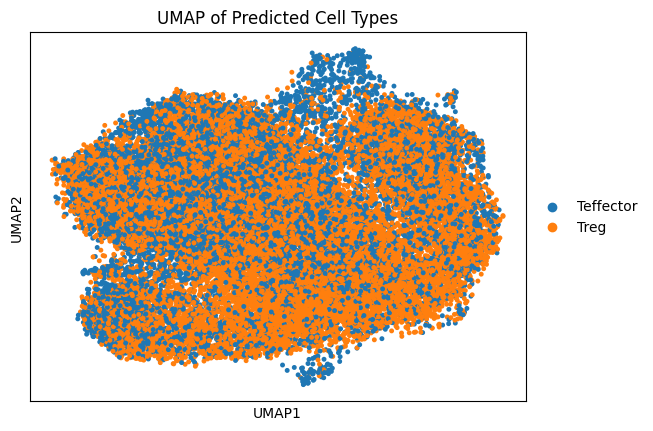

In [15]:
import scanpy as sc
import numpy as np

# Check data shape
print("Data shape:", filtered_wend_adata.shape)

# Check for invalid values
print("Checking for NaNs or Infs...")
if np.any(np.isnan(filtered_wend_adata.X)) or np.any(np.isinf(filtered_wend_adata.X)):
    print("Invalid values found. Fixing...")
    filtered_wend_adata.X[np.isnan(filtered_wend_adata.X)] = 0
    filtered_wend_adata.X[np.isinf(filtered_wend_adata.X)] = np.nanmax(filtered_wend_adata.X[np.isfinite(filtered_wend_adata.X)])
else:
    print("No invalid values found.")

# Check PCA
if "X_pca" not in filtered_wend_adata.obsm.keys():
    print("PCA not computed. Computing PCA...")
    sc.tl.pca(filtered_wend_adata)
    print("PCA computed.")

# Compute neighbors
print("Computing neighbors using PCA representation...")
sc.pp.neighbors(filtered_wend_adata, n_neighbors=15, use_rep="X_pca")

# Compute UMAP
print("Computing UMAP...")
sc.tl.umap(filtered_wend_adata)

# Plot UMAP
sc.pl.umap(
    filtered_wend_adata,
    color="cell_predictions",
    title="UMAP of Predicted Cell Types",
    size=50
)


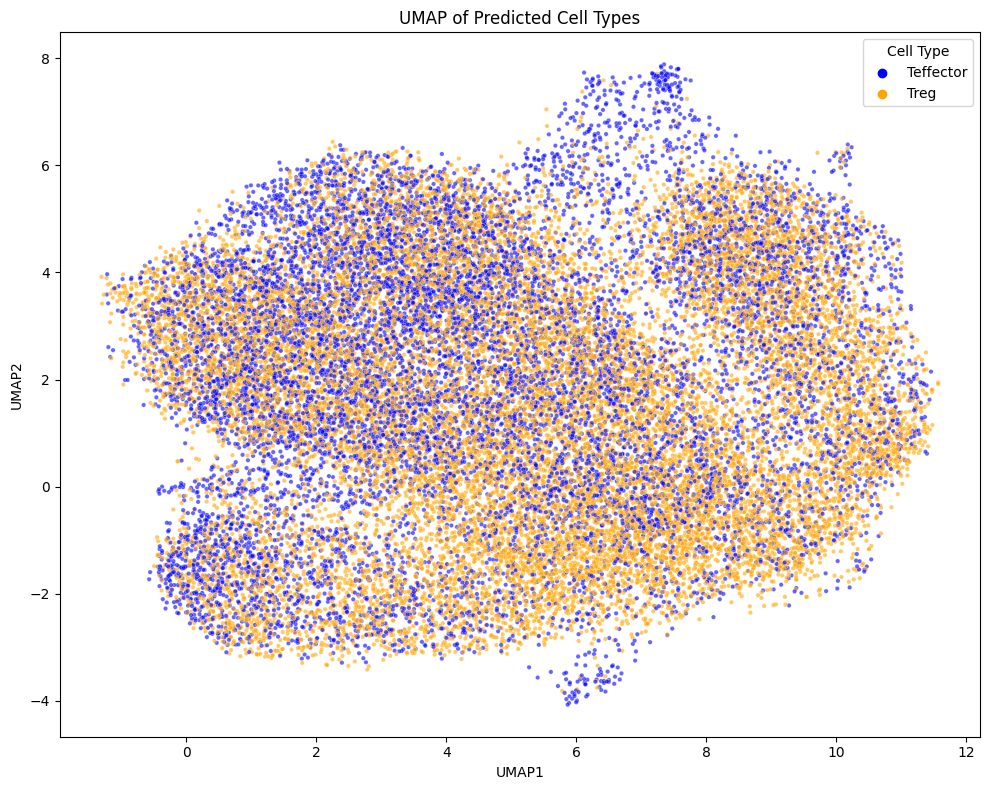

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract UMAP coordinates and predictions
umap_data = filtered_wend_adata.obsm["X_umap"]
predictions = filtered_wend_adata.obs["cell_predictions"]

# Create a scatter plot with density overlay
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=umap_data[:, 0],
    y=umap_data[:, 1],
    hue=predictions,
    palette={"Treg": "orange", "Teffector": "blue"},
    s=10,  # Marker size
    alpha=0.6  # Transparency
)
plt.title("UMAP of Predicted Cell Types")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title="Cell Type", loc="best")
plt.tight_layout()
plt.show()


### **explainability: get top genes**

In [31]:
# Convert the indices in filtered_wend_adata.obs to strings
filtered_wend_adata.obs.index = filtered_wend_adata.obs.index.astype(str)

#run explainability analysis
explainability_matrix = sims.explain(filtered_wend_adata, num_workers=0, batch_size=32)[0]

# convert explainability matrix to a DataFrame
explain_df = pd.DataFrame(explainability_matrix, columns=sims.model.genes)

# compute average gene importance
gene_importance = explain_df.mean(axis=0)

# identify top 10 most important genes
top10_genes = gene_importance.nlargest(10)
print("Top 10 most important genes:")
print(top10_genes)

Computing explainability matrix ...


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Inference data has 11645 less genes than training; performing zero inflation.


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/merge.py:1111: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
100%|██████████| 928/928 [25:21<00:00,  1.64s/it]


Top 10 most important genes:
TOMM7        0.268235
SHMT2        0.149996
RPS21        0.147597
ATG16L1      0.141177
IER5L-AS1    0.130736
NEURL2       0.129821
HLA-DRB5     0.112413
TRMO         0.111588
ABCG1        0.107288
TCF7         0.101643
dtype: float64


In [100]:
# Check the number of cells (observations) in the data
num_cells = filtered_wend_adata.n_obs
print(f"Number of cells in the data: {num_cells}")


Number of cells in the data: 29668


In [32]:
print(top10_genes)
top_genes_filtered = [gene for gene in top10_genes if gene in filtered_wend_adata.var_names]

if not top_genes_filtered:
    print("None of the top genes are present in the dataset.")
else:
    print(f"Filtered Top Genes for UMAP: {top_genes_filtered}")


TOMM7        0.268235
SHMT2        0.149996
RPS21        0.147597
ATG16L1      0.141177
IER5L-AS1    0.130736
NEURL2       0.129821
HLA-DRB5     0.112413
TRMO         0.111588
ABCG1        0.107288
TCF7         0.101643
dtype: float64
None of the top genes are present in the dataset.


In [94]:
try:
    explainability_matrix = sims.explain(filtered_wend_adata, num_workers=0, batch_size=8)[0]
    print(f"Explainability matrix shape: {explainability_matrix.shape}")
except Exception as e:
    print(f"Error during sims.explain execution: {e}")
    raise


Computing explainability matrix ...
Inference data has 11645 less genes than training; performing zero inflation.


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/merge.py:1111: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
  0%|          | 0/3709 [00:00<?, ?it/s]


Error during sims.explain execution: index -1 is out of bounds for dimension 1 with size 14363


RuntimeError: index -1 is out of bounds for dimension 1 with size 14363

In [99]:
# Ensure all genes in sims.model.genes and filtered_wend_adata.var_names are strings
sims_genes = [str(gene) for gene in sims.model.genes]
adata_genes = [str(gene) for gene in filtered_wend_adata.var_names]
model_list = list(set(sims_genes))
data_list = list(set(adata_genes))

# Identify overlapping genes
overlapping_genes = list(set(sims_genes) & set(adata_genes))

# Check if overlapping_genes is valid
if not overlapping_genes:
    raise ValueError("No overlapping genes found between the model and the test dataset.")
print(f"Number of overlapping genes: {len(overlapping_genes)}")
print(f"Number of model genes: {len(model_list)}")

print(f"Number of data genes: {len(data_list)}")

print(f"Sample of overlapping genes: {overlapping_genes[:5]}")



Number of overlapping genes: 2718
Number of model genes: 14363
Number of data genes: 3062
Sample of overlapping genes: ['KNTC1', 'GTF3C1', 'LRRC8D', 'CHAF1A', 'DCP1B']


In [83]:
print(f"Filtered data shape: {filtered_wend_adata.shape}")
print(f"Number of cells (n_obs): {filtered_wend_adata.n_obs}, Number of genes (n_vars): {filtered_wend_adata.n_vars}")


Filtered data shape: (29668, 2718)
Number of cells (n_obs): 29668, Number of genes (n_vars): 2718


## luo data

In [113]:

luo_adata_name = 'fer_cd4_treg_ngs_final.h5ad'
luo_adata_path = '/Users/zoezabetian/Desktop/M-R-lab/immune-sims/leo_data/' + luo_adata_name
luo_checkpoint_name = "luo_best_model.ckpt"
luo_checkpoint_path = '/Users/zoezabetian/Desktop/M-R-lab/immune-sims/models/' + luo_checkpoint_name
luo_adata = sc.read_h5ad(luo_adata_path)

# Preprocessing
sc.pp.filter_cells(luo_adata, min_genes=100)
sc.pp.filter_genes(luo_adata, min_cells=3)
# sc.pp.normalize_total(adata)
# ### Logarithmizing the data
# sc.pp.log1p(adata)
sc.pp.scale(luo_adata)


#check size of dataset
luo_adata.obs.reset_index(inplace=True)
print(luo_adata)

sims = SIMS(weights_path=luo_checkpoint_path,map_location=torch.device('cpu'))
# print("Model genes")
# print(sims.model.genes)
print("Dataset gene names")
print(luo_adata.var_names)
print(luo_adata.n_obs)


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 48686 × 3062
    obs: 'index', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nUMI', 'nGene', 'sample', 'pMito', 'patient', 'act_tcell', 'tcell_type', 'activation', 'mito_filter_out', 'numi_out', 'all_out', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'integrated_snn_res.0.9', 'integrated_snn_res.1', 'integrated_snn_res.1.1', 'integrated_snn_res.1.2', 'seurat_clusters', 'scDblFinder.class', 'garnett_celltypes', 'activation_status', 'Cell', 'Cluster1', 'Cluster2', 'down_treg', 'up_treg', 'clusters', 'S.Score', 'G2M.Score', 'Phase', 'treg_score', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'RNA_snn_res.1.1', 'RNA_snn_res.1.2', 'n_genes'
    var: 'featu

### ensure we are looking at Tregs

In [16]:
unique_orig_ident = luo_adata.obs['tcell_type'].unique()

# Print the unique values
print("Unique values in 'tcell_type':")
print(unique_orig_ident)

Unique values in 'tcell_type':
['Treg']


### make predictions

In [34]:
cell_predictions = sims.predict(luo_adata, num_workers=0)
cell_predictions = cell_predictions.reset_index(drop=True)
# luo_adata.obs.to_csv(f'{luo_adata_name}-{luo_checkpoint_name}.csv', index=False)
#join cell predictions with adata
luo_adata.obs = luo_adata.obs.join(cell_predictions)
luo_adata.obs['cell_predictions'] = cell_predictions['pred_0'].values
luo_adata.obs['prob_0'] = cell_predictions['prob_0'].values
luo_adata.obs['prob_1'] = cell_predictions['prob_1'].values
total_cells = len(luo_adata.obs)
counts = luo_adata.obs['cell_predictions'].value_counts()
percentages = (counts / total_cells) * 100

# print the percentages
for cell_type, percentage in percentages.items():
    print(f"{cell_type}: {percentage:.2f}% of total cells")

Parsing inference data...


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Inference data has 11993 less genes than training; performing zero inflation.


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/merge.py:1111: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(
100%|██████████| 1522/1522 [01:08<00:00, 22.37it/s]


effector: 66.43% of total cells
naive: 33.57% of total cells


In [35]:
# Filter AnnData object to exclude all "NoAct" samples
filtered_adata_luo = luo_adata[~luo_adata.obs['sample'].str.contains("NoAct"), :]

# # Verify the filtering worked
# print("Filtered DataFrame:")
# print(filtered_adata_luo)

# Get unique samples from the filtered data
unique_samples = filtered_adata_luo.obs['sample'].unique()

# Display predictions for each sample
for sample in unique_samples:
    # Filter data for the current sample within filtered_adata
    sample_data = filtered_adata_luo.obs[filtered_adata_luo.obs['sample'] == sample]
    
    # Count predictions (no percentages, just counts)
    prediction_counts = sample_data['cell_predictions'].value_counts()
    
    # Calculate percentages
    total_count = len(sample_data)
    prediction_percentages = (prediction_counts / total_count) * 100
    
    # Ensure order: Treg first, then Teffector
    treg_percent = prediction_percentages.get('naive', 0)
    teff_percent = prediction_percentages.get('effector', 0)
    
    # Print results
    print(f"Sample: {sample}")
    print(f"Treg: {treg_percent:.2f}%")
    print(f"Teffector: {teff_percent:.2f}%")
    print("-" * 40)

Sample: P11_Treg_CAR
Treg: 37.47%
Teffector: 62.53%
----------------------------------------
Sample: P11_Treg_TCR
Treg: 48.73%
Teffector: 51.27%
----------------------------------------
Sample: P12_Treg_CAR
Treg: 52.06%
Teffector: 47.94%
----------------------------------------
Sample: P12_Treg_TCR
Treg: 28.80%
Teffector: 71.20%
----------------------------------------


## Test generalizability 
### see if wend model generalizes well by predicting on luo data and vice versa

In [56]:
adata_mix1_path = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/luo_files/Luo2021nature_new_labels.h5ad'
wend_checkpoint_name = "wend_best_model.ckpt"
wend_checkpoint_path = f'/Users/zoezabetian/Desktop/M-R-lab/immune-sims/models/{wend_checkpoint_name}'

# Load data
adata_mix1 = sc.read_h5ad(adata_mix1_path)

# Preprocessing
sc.pp.filter_cells(adata_mix1, min_genes=100)
sc.pp.filter_genes(adata_mix1, min_cells=3)
adata_mix1.var_names_make_unique()
sc.pp.normalize_total(adata_mix1, target_sum=1e4)
sc.pp.log1p(adata_mix1)
sc.pp.scale(adata_mix1)

# Reset index in obs and check size of dataset
adata_mix1.obs.reset_index(inplace=True)
print("Initial adata_mix1.obs structure:")
print(adata_mix1.obs.head())

# Load model
sims = SIMS(weights_path=wend_checkpoint_path, map_location=torch.device('cpu'))

# Check dataset gene names (optional)
print("Dataset gene names:")
print(adata_mix1.var_names)

# Predict cell types
cell_predictions = sims.predict(adata_mix1, num_workers=0)
cell_predictions = cell_predictions.reset_index(drop=True)

# Join predictions with adata
adata_mix1.obs = adata_mix1.obs.join(cell_predictions)
adata_mix1.obs['cell_predictions'] = cell_predictions['pred_0'].values
adata_mix1.obs['prob_0'] = cell_predictions['prob_0'].values
adata_mix1.obs['prob_1'] = cell_predictions['prob_1'].values

# Map 'effector' to 'Teff' and 'naive' to 'Treg'
mapping = {'effector': 'Teff', 'naive': 'Treg'}
adata_mix1.obs['treg_mapped'] = adata_mix1.obs['treg'].map(mapping)

# Debug: Check if the mapping worked
print("Unique values in the 'treg_mapped' column:")
print(adata_mix1.obs['treg_mapped'].unique())

# Filter for Tregs in the test set
treg_data = adata_mix1.obs[adata_mix1.obs['treg_mapped'] == "Treg"]

# Debug: Check filtered Treg data
if treg_data.empty:
    print("No rows found for 'treg_mapped' == 'Treg'. Check the mapping or data!")
else:
    print("Filtered Treg data:")
    print(treg_data.head())

    # Count predictions for Tregs
    prediction_counts = treg_data['cell_predictions'].value_counts()

    # Calculate percentages
    total_count = len(treg_data)
    prediction_percentages = (prediction_counts / total_count) * 100

    # Ensure order: Treg first, then Teffector
    treg_percent = prediction_percentages.get('Treg', 0)
    teff_percent = prediction_percentages.get('Teffector', 0)

    # Print results
    print("Predictions for Tregs in the test set:")
    print(f"Treg: {treg_percent:.2f}%")
    print(f"Teffector: {teff_percent:.2f}%")
    print("-" * 40)


Initial adata_mix1.obs structure:
                index      treg  n_genes
0  AAACCTGAGAAACCGC_6  effector     1095
1  AAACCTGAGACACTAA_7  effector      970
2  AAACCTGAGACAGGCT_7  effector     1156
3  AAACCTGAGACCTTTG_6  effector      652
4  AAACCTGAGACGCTTT_5  effector     1116
Initializing network
Initializing explain matrix
Dataset gene names:
Index(['AL669831.5', 'LINC00115', 'FAM41C', 'NOC2L', 'KLHL17', 'PLEKHN1',
       'ISG15', 'C1orf159', 'TNFRSF18', 'TNFRSF4',
       ...
       'C4orf50', 'AC024581.1', 'TRBJ2-4', 'ZC3H12C', 'SMIM35', 'IQSEC3',
       'AC009509.1', 'AC025165.2', 'TP53TG3D', 'TLDC2'],
      dtype='object', length=14628)
Parsing inference data...


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Inference data has 2391 less genes than training; performing zero inflation.


100%|██████████| 219/219 [00:09<00:00, 22.59it/s]

Unique values in the 'treg_mapped' column:
['Teff', 'Treg']
Categories (2, object): ['Teff', 'Treg']
Filtered Treg data:
                  index   treg  n_genes     pred_0 pred_1    prob_0    prob_1   
304  AAGGCAGTCAGGTAAA_4  naive      835  Teffector   Treg  0.541698  0.458302  \
308  ACCGTAACAGTGGAGT_7  naive     1051  Teffector   Treg  0.879068  0.120932   
310  ACCGTAACATCCGGGT_7  naive     1140  Teffector   Treg  0.909235  0.090765   
311  ACCGTAAGTAAGAGAG_7  naive     1011  Teffector   Treg  0.887274  0.112726   
312  ACCGTAAGTGACTACT_7  naive      973  Teffector   Treg  0.844882  0.155118   

    cell_predictions treg_mapped  
304        Teffector        Treg  
308        Teffector        Treg  
310        Teffector        Treg  
311        Teffector        Treg  
312        Teffector        Treg  
Predictions for Tregs in the test set:
Treg: 29.72%
Teffector: 70.28%
----------------------------------------


In [71]:
# File paths
adata_mix1_path = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/luo_files/Luo2021nature_new_labels.h5ad'
wend_checkpoint_name = "wend_best_model.ckpt"
wend_checkpoint_path = f'/Users/zoezabetian/Desktop/M-R-lab/immune-sims/models/{wend_checkpoint_name}'

# Load data
adata_mix1 = sc.read_h5ad(adata_mix1_path)

# Preprocessing
sc.pp.filter_cells(adata_mix1, min_genes=100)
sc.pp.filter_genes(adata_mix1, min_cells=3)
adata_mix1.var_names_make_unique()
sc.pp.normalize_total(adata_mix1, target_sum=1e4)
sc.pp.log1p(adata_mix1)
sc.pp.scale(adata_mix1)

# Reset index in obs
adata_mix1.obs.reset_index(inplace=True)

# Debug: Check initial structure
print("Initial adata_mix1.obs structure:")
print(adata_mix1.obs.head())

# Load model
sims = SIMS(weights_path=wend_checkpoint_path, map_location=torch.device('cpu'))

# Predict cell types
print("Running SIMS predictions...")
cell_predictions = sims.predict(adata_mix1, num_workers=0)
cell_predictions = cell_predictions.reset_index(drop=True)

# Join predictions with adata
adata_mix1.obs = adata_mix1.obs.join(cell_predictions)
adata_mix1.obs['cell_predictions'] = cell_predictions['pred_0'].values
adata_mix1.obs['prob_0'] = cell_predictions['prob_0'].values
adata_mix1.obs['prob_1'] = cell_predictions['prob_1'].values

# Debug: Check predictions
print("Unique values in 'cell_predictions':", adata_mix1.obs['cell_predictions'].unique())

# Map 'effector' to 'Teff' and 'naive' to 'Treg'
mapping = {'effector': 'Teffector', 'naive': 'Treg'}
adata_mix1.obs['treg_mapped'] = adata_mix1.obs['treg'].map(mapping)

# Debug: Check mapping
print("Unique values in 'treg_mapped':", adata_mix1.obs['treg_mapped'].unique())

true_treg_data = adata_mix1.obs[adata_mix1.obs['treg_mapped'] == "Treg"]

if true_treg_data.empty:
    print("No rows found for 'treg_mapped' cells. Check the mapping data!")
else:
    # Count predictions for `Treg` cells
    prediction_counts = true_treg_data['pred_0'].value_counts()

    # Calculate percentages
    total_count = len(true_treg_data)
    prediction_percentages = (prediction_counts / total_count) * 100

    # Print results
    print("Predictions for 'Treg' cells in the Wend data:")
    for label, percentage in prediction_percentages.items():
        print(f"{label}: {percentage:.2f}%")
    print("-" * 40)

# Analyze predictions for `Teffector` cells in the Wend data
true_teffector_data = adata_mix1.obs[adata_mix1.obs['treg_mapped'] == "Teffector"]

if true_teffector_data.empty:
    print("No rows found for 'Teffector' cells. Check the test data!")
else:
    # Count predictions for `Teffector` cells
    prediction_counts = true_teffector_data['pred_0'].value_counts()

    # Calculate percentages
    total_count = len(true_teffector_data)
    prediction_percentages = (prediction_counts / total_count) * 100

    # Print results
    print("Predictions for 'Teffector' cells in the Wend data:")
    for label, percentage in prediction_percentages.items():
        print(f"{label}: {percentage:.2f}%")
    print("-" * 40)


Initial adata_mix1.obs structure:
                index      treg  n_genes
0  AAACCTGAGAAACCGC_6  effector     1095
1  AAACCTGAGACACTAA_7  effector      970
2  AAACCTGAGACAGGCT_7  effector     1156
3  AAACCTGAGACCTTTG_6  effector      652
4  AAACCTGAGACGCTTT_5  effector     1116
Initializing network
Initializing explain matrix
Running SIMS predictions...
Parsing inference data...


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Inference data has 2391 less genes than training; performing zero inflation.


100%|██████████| 219/219 [00:09<00:00, 23.57it/s]

Unique values in 'cell_predictions': ['Treg' 'Teffector']
Unique values in 'treg_mapped': ['Teffector', 'Treg']
Categories (2, object): ['Teffector', 'Treg']
Predictions for 'Treg' cells in the Wend data:
Teffector: 70.28%
Treg: 29.72%
----------------------------------------
Predictions for 'Teffector' cells in the Wend data:
Treg: 57.82%
Teffector: 42.18%
----------------------------------------


In [68]:
# Create a column indicating whether the prediction matches the true label
adata_mix1.obs['correct'] = adata_mix1.obs['treg'] == adata_mix1.obs['treg']

# Debug: Check counts of correct and incorrect predictions
print("Prediction Accuracy:")
print(adata_mix1.obs['correct'].value_counts())
# Average confidence scores for correct and incorrect predictions
confidence_analysis = adata_mix1.obs.groupby('correct').agg({
    'prob_0': 'mean',
    'prob_1': 'mean'
})
print("\n\nConfidence Scores (Correct vs. Incorrect Predictions):")
print(confidence_analysis)


Prediction Accuracy:
correct
True    6991
Name: count, dtype: int64


Confidence Scores (Correct vs. Incorrect Predictions):
           prob_0    prob_1
correct                    
True     0.858279  0.141721


In [62]:
import scanpy as sc
import torch
from scsims import SIMS  # Ensure SIMS is available in your environment

# File paths
adata_mix2_path = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/wend_files/Wend2024sciadv_two_labels.h5ad'
luo_checkpoint_name = "luo_best_model.ckpt"
luo_checkpoint_path = f'/Users/zoezabetian/Desktop/M-R-lab/immune-sims/models/{luo_checkpoint_name}'

# Load Wend dataset
adata_mix2 = sc.read_h5ad(adata_mix2_path)

# **No mapping**: Use Wend labels directly for analysis
print("Labels in 'treg':", adata_mix2.obs['treg'].unique())

# Preprocessing
sc.pp.filter_cells(adata_mix2, min_genes=50)
sc.pp.filter_genes(adata_mix2, min_cells=2)
adata_mix2.var_names_make_unique()

# Normalize, log-transform, and scale the dataset
sc.pp.normalize_total(adata_mix2, target_sum=1e4)
sc.pp.log1p(adata_mix2)
sc.pp.scale(adata_mix2)

# Clear previous prediction columns if they exist
columns_to_remove = ['cell_predictions', 'prob_0', 'prob_1', 'pred_0', 'pred_1']
adata_mix2.obs = adata_mix2.obs.drop(columns=[col for col in columns_to_remove if col in adata_mix2.obs])

# Load the Luo-trained SIMS model
sims = SIMS(weights_path=luo_checkpoint_path, map_location=torch.device('cpu'))

# Predict cell types
print("Running SIMS predictions...")
cell_predictions = sims.predict(adata_mix2, num_workers=0)

# Ensure indices align
cell_predictions.index = adata_mix2.obs.index
print("Cell predictions head:")
print(cell_predictions.head())

# Join predictions with adata
adata_mix2.obs = adata_mix2.obs.join(cell_predictions)

# Debug: Verify predictions were added
print("Columns in adata_mix2.obs after joining:")
print(adata_mix2.obs.columns)
print("Sample predictions in adata_mix2.obs:")
print(adata_mix2.obs[['pred_0', 'pred_1', 'prob_0', 'prob_1']].head())

# Analyze predictions for `Treg` cells in the Wend data
true_treg_data = adata_mix2.obs[adata_mix2.obs['treg'] == "Treg"]

if true_treg_data.empty:
    print("No rows found for 'Treg' cells. Check the test data!")
else:
    # Count predictions for `Treg` cells
    prediction_counts = true_treg_data['pred_0'].value_counts()

    # Calculate percentages
    total_count = len(true_treg_data)
    prediction_percentages = (prediction_counts / total_count) * 100

    # Print results
    print("Predictions for 'Treg' cells in the Wend data:")
    for label, percentage in prediction_percentages.items():
        print(f"{label}: {percentage:.2f}%")
    print("-" * 40)

# Analyze predictions for `Teffector` cells in the Wend data
true_teffector_data = adata_mix2.obs[adata_mix2.obs['treg'] == "Teffector"]

if true_teffector_data.empty:
    print("No rows found for 'Teffector' cells. Check the test data!")
else:
    # Count predictions for `Teffector` cells
    prediction_counts = true_teffector_data['pred_0'].value_counts()

    # Calculate percentages
    total_count = len(true_teffector_data)
    prediction_percentages = (prediction_counts / total_count) * 100

    # Print results
    print("Predictions for 'Teffector' cells in the Wend data:")
    for label, percentage in prediction_percentages.items():
        print(f"{label}: {percentage:.2f}%")
    print("-" * 40)

# Optional: Save updated AnnData object with predictions
# adata_mix2.write('/path/to/output/adata_mix2_with_predictions.h5ad')


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Labels in 'treg': ['Teffector', 'Treg']
Categories (2, object): ['Teffector', 'Treg']


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Initializing network
Initializing explain matrix
Running SIMS predictions...
Parsing inference data...
Inference data has 2585 less genes than training; performing zero inflation.


100%|██████████| 606/606 [00:28<00:00, 21.32it/s]

Cell predictions head:
                            pred_0    pred_1    prob_0    prob_1
CoTP8_ACTTGTTCACAGAGGT-1     naive  effector  0.513685  0.486315
CoTP8_ACACCCTAGCGTAATA-1     naive  effector  0.546056  0.453944
CoTP2_TTCTCAAAGACCACGA-1  effector     naive  0.532355  0.467645
CoTP8_CTCTAATTCACGATGT-1     naive  effector  0.545771  0.454229
CoTP4_AAGGCAGAGGTGATAT-1  effector     naive  0.590489  0.409511
Columns in adata_mix2.obs after joining:
Index(['treg', 'n_genes', 'pred_0', 'pred_1', 'prob_0', 'prob_1'], dtype='object')
Sample predictions in adata_mix2.obs:
                            pred_0    pred_1    prob_0    prob_1
CoTP8_ACTTGTTCACAGAGGT-1     naive  effector  0.513685  0.486315
CoTP8_ACACCCTAGCGTAATA-1     naive  effector  0.546056  0.453944
CoTP2_TTCTCAAAGACCACGA-1  effector     naive  0.532355  0.467645
CoTP8_CTCTAATTCACGATGT-1     naive  effector  0.545771  0.454229
CoTP4_AAGGCAGAGGTGATAT-1  effector     naive  0.590489  0.409511
Predictions for 'Treg' cells in the

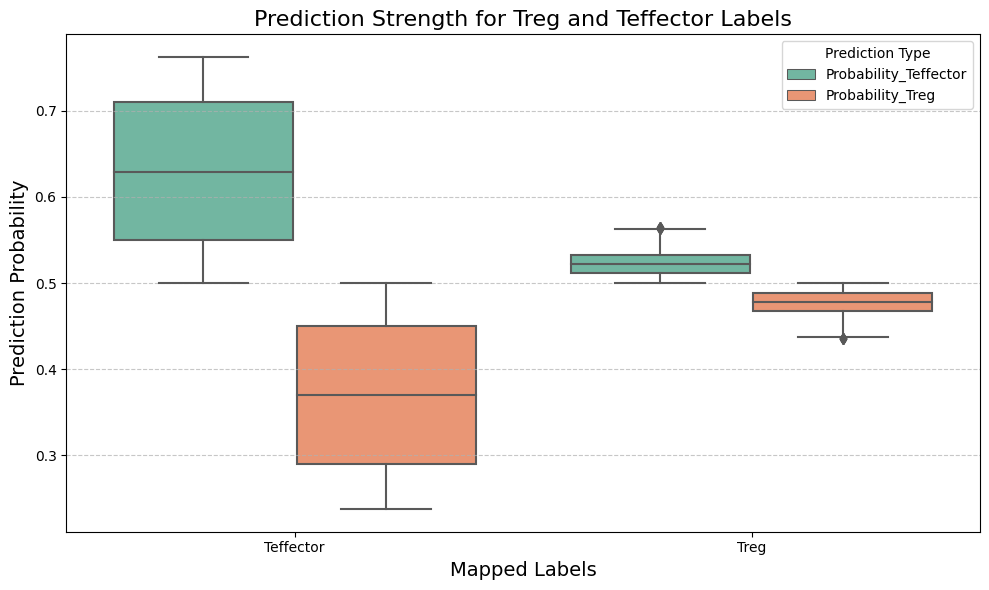

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for box plots
# Extract relevant columns
boxplot_data = adata_mix2.obs[['mapped_predictions', 'prob_0', 'prob_1']].copy()

# Rename columns for better readability
boxplot_data.rename(columns={'prob_0': 'Probability_Teffector', 'prob_1': 'Probability_Treg'}, inplace=True)

# Melt the data for seaborn
melted_data = boxplot_data.melt(id_vars='mapped_predictions', 
                                value_vars=['Probability_Teffector', 'Probability_Treg'], 
                                var_name='Prediction_Type', 
                                value_name='Probability')

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=melted_data, x='mapped_predictions', y='Probability', hue='Prediction_Type', palette='Set2')

# Customize the plot
plt.title('Prediction Strength for Treg and Teffector Labels', fontsize=16)
plt.xlabel('Mapped Labels', fontsize=14)
plt.ylabel('Prediction Probability', fontsize=14)
plt.legend(title='Prediction Type', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [35]:
# Create a column indicating whether the prediction matches the true label
adata_mix2.obs['correct'] = adata_mix2.obs['mapped_predictions'] == adata_mix2.obs['treg']

# Debug: Check counts of correct and incorrect predictions
print("Prediction Accuracy:")
print(adata_mix2.obs['correct'].value_counts())
# Average confidence scores for correct and incorrect predictions
confidence_analysis = adata_mix2.obs.groupby('correct').agg({
    'prob_0': 'mean',
    'prob_1': 'mean'
})
print("\n\nConfidence Scores (Correct vs. Incorrect Predictions):")
print(confidence_analysis)


Prediction Accuracy:
correct
False    13699
True      5687
Name: count, dtype: int64


Confidence Scores (Correct vs. Incorrect Predictions):
           prob_0    prob_1
correct                    
False    0.606119  0.393881
True     0.553561  0.446439


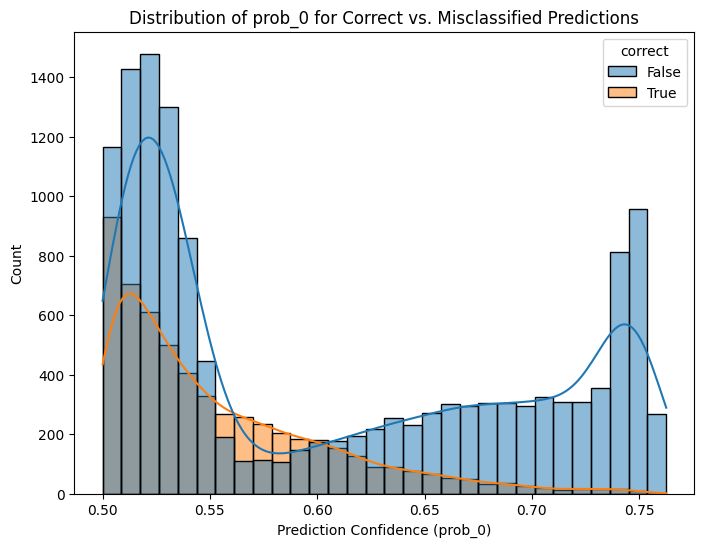

In [40]:
import seaborn as sns

# Correct and Incorrect
adata_mix2.obs['correct'] = adata_mix2.obs['mapped_predictions'] == adata_mix2.obs['treg']

plt.figure(figsize=(8, 6))
sns.histplot(data=adata_mix2.obs, x='prob_0', hue='correct', bins=30, kde=True)
plt.title("Distribution of prob_0 for Correct vs. Misclassified Predictions")
plt.xlabel("Prediction Confidence (prob_0)")
plt.ylabel("Count")
plt.show()


prove that model works by predicting wend with wend model

In [54]:
# File paths
wend2_path = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/wend_files/Wend2024sciadv_two_labels.h5ad'
wend_checkpoint_name = "wend_best_model.ckpt"
wend_checkpoint_path = f'/Users/zoezabetian/Desktop/M-R-lab/immune-sims/models/{wend_checkpoint_name}'

# Load data
adata_wend2 = sc.read_h5ad(wend2_path)

# Ensure data is in float32 format
if adata_wend2.X.dtype != "float32":
    adata_wend2.X = adata_wend2.X.astype("float32")
    print("Converted adata_wend2.X to float32.")

# Preprocessing
sc.pp.filter_cells(adata_wend2, min_genes=100)
sc.pp.filter_genes(adata_wend2, min_cells=3)
adata_wend2.var_names_make_unique()

# Clear previous prediction columns if they exist
columns_to_remove = ['cell_predictions', 'prob_0', 'prob_1', 'pred_0', 'pred_1']
adata_wend2.obs = adata_wend2.obs.drop(columns=[col for col in columns_to_remove if col in adata_wend2.obs])

# Load the SIMS model
sims = SIMS(weights_path=wend_checkpoint_path, map_location=torch.device('cpu'))

# Predict cell types
print("Running SIMS predictions...")
cell_predictions = sims.predict(adata_wend2, num_workers=0)

# Ensure indices align
cell_predictions.index = adata_wend2.obs.index  # Match indices
print("Cell predictions head:")
print(cell_predictions.head())

# Join predictions with adata
adata_wend2.obs = adata_wend2.obs.join(cell_predictions)

# Debug: Ensure predictions were added
print("Columns in adata_wend2.obs after joining:")
print(adata_wend2.obs.columns)
print("Sample predictions in adata_wend2.obs:")
print(adata_wend2.obs[['pred_0', 'pred_1', 'prob_0', 'prob_1']].head())

# Analyze predictions for Tregs
treg_data = adata_wend2.obs[adata_wend2.obs['treg'] == "Treg"]

if treg_data.empty:
    print("No rows found for 'treg' == 'Treg'. Check the test data!")
else:
    # Count predictions for Tregs
    prediction_counts = treg_data['pred_0'].value_counts()

    # Calculate percentages
    total_count = len(treg_data)
    prediction_percentages = (prediction_counts / total_count) * 100

    # Print results
    print("Predictions for Tregs in the test set:")
    for label, percentage in prediction_percentages.items():
        print(f"{label}: {percentage:.2f}%")
    print("-" * 40)

# Optional: Save the updated AnnData object
# adata_wend2.write('/path/to/output/adata_wend2_with_predictions.h5ad')


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Converted adata_wend2.X to float32.


/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Initializing network
Initializing explain matrix
Running SIMS predictions...
Parsing inference data...


100%|██████████| 606/606 [00:25<00:00, 23.98it/s]

Cell predictions head:
                             pred_0     pred_1    prob_0    prob_1
CoTP8_ACTTGTTCACAGAGGT-1  Teffector       Treg  0.887735  0.112265
CoTP8_ACACCCTAGCGTAATA-1       Treg  Teffector  0.950583  0.049417
CoTP2_TTCTCAAAGACCACGA-1       Treg  Teffector  0.947932  0.052067
CoTP8_CTCTAATTCACGATGT-1  Teffector       Treg  0.548937  0.451063
CoTP4_AAGGCAGAGGTGATAT-1       Treg  Teffector  0.952988  0.047012
Columns in adata_wend2.obs after joining:
Index(['treg', 'n_genes', 'pred_0', 'pred_1', 'prob_0', 'prob_1'], dtype='object')
Sample predictions in adata_wend2.obs:
                             pred_0     pred_1    prob_0    prob_1
CoTP8_ACTTGTTCACAGAGGT-1  Teffector       Treg  0.887735  0.112265
CoTP8_ACACCCTAGCGTAATA-1       Treg  Teffector  0.950583  0.049417
CoTP2_TTCTCAAAGACCACGA-1       Treg  Teffector  0.947932  0.052067
CoTP8_CTCTAATTCACGATGT-1  Teffector       Treg  0.548937  0.451063
CoTP4_AAGGCAGAGGTGATAT-1       Treg  Teffector  0.952988  0.047012
Predictio

prove that luo model works on itself

In [66]:
# File paths
luo2_path = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/luo_files/Luo2021nature_new_labels.h5ad'
luo_checkpoint_name = "luo_best_model.ckpt"
luo_checkpoint_path = f'/Users/zoezabetian/Desktop/M-R-lab/immune-sims/models/{luo_checkpoint_name}'

# Load data
adata_luo2 = sc.read_h5ad(luo2_path)

# Ensure data is in float32 format
if adata_luo2.X.dtype != "float32":
    adata_luo2.X = adata_luo2.X.astype("float32")
    print("Converted adata_luo2.X to float32.")

# Preprocessing
sc.pp.filter_cells(adata_luo2, min_genes=100)
sc.pp.filter_genes(adata_luo2, min_cells=3)
adata_luo2.var_names_make_unique()
sc.pp.normalize_total(adata_luo2, target_sum=1e4)
sc.pp.log1p(adata_luo2)
sc.pp.scale(adata_luo2)

# Clear previous prediction columns if they exist
columns_to_remove = ['cell_predictions', 'prob_0', 'prob_1', 'pred_0', 'pred_1']
adata_luo2.obs = adata_luo2.obs.drop(columns=[col for col in columns_to_remove if col in adata_luo2.obs])

# Load the SIMS model
sims = SIMS(weights_path=luo_checkpoint_path, map_location=torch.device('cpu'))

# Predict cell types
print("Running SIMS predictions...")
cell_predictions = sims.predict(adata_luo2, num_workers=0)

# Ensure indices align
cell_predictions.index = adata_luo2.obs.index  # Match indices
print("Cell predictions head:")
print(cell_predictions.head())

# Join predictions with adata
adata_luo2.obs = adata_luo2.obs.join(cell_predictions)

# Debug: Ensure predictions were added
print("Columns in adata_luo2.obs after joining:")
print(adata_luo2.obs.columns)
print("Sample predictions in adata_luo2.obs:")
print(adata_luo2.obs[['pred_0', 'pred_1', 'prob_0', 'prob_1']].head())

# Analyze predictions for Tregs
treg_data = adata_luo2.obs[adata_luo2.obs['treg'] == "naive"]

if treg_data.empty:
    print("No rows found for 'treg' == 'Treg'. Check the test data!")
else:
    # Count predictions for Tregs
    prediction_counts = treg_data['pred_0'].value_counts()

    # Calculate percentages
    total_count = len(treg_data)
    prediction_percentages = (prediction_counts / total_count) * 100

    # Print results
    print("Predictions for Tregs in the test set:")
    for label, percentage in prediction_percentages.items():
        print(f"{label}: {percentage:.2f}%")
    print("-" * 40)

# Optional: Save the updated AnnData object
# adata_wend2.write('/path/to/output/adata_wend2_with_predictions.h5ad')


Initializing network
Initializing explain matrix
Running SIMS predictions...
Parsing inference data...


100%|██████████| 219/219 [00:10<00:00, 21.14it/s]

Cell predictions head:
                      pred_0 pred_1    prob_0    prob_1
AAACCTGAGAAACCGC_6  effector  naive  0.618835  0.381164
AAACCTGAGACACTAA_7  effector  naive  0.520779  0.479221
AAACCTGAGACAGGCT_7  effector  naive  0.559437  0.440563
AAACCTGAGACCTTTG_6  effector  naive  0.512060  0.487941
AAACCTGAGACGCTTT_5  effector  naive  0.552318  0.447682
Columns in adata_luo2.obs after joining:
Index(['treg', 'n_genes', 'pred_0', 'pred_1', 'prob_0', 'prob_1'], dtype='object')
Sample predictions in adata_luo2.obs:
                      pred_0 pred_1    prob_0    prob_1
AAACCTGAGAAACCGC_6  effector  naive  0.618835  0.381164
AAACCTGAGACACTAA_7  effector  naive  0.520779  0.479221
AAACCTGAGACAGGCT_7  effector  naive  0.559437  0.440563
AAACCTGAGACCTTTG_6  effector  naive  0.512060  0.487941
AAACCTGAGACGCTTT_5  effector  naive  0.552318  0.447682
Predictions for Tregs in the test set:
naive: 90.49%
effector: 9.51%
----------------------------------------


### Using harmony to combine wend and luo datasets to view UMAP

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: htt

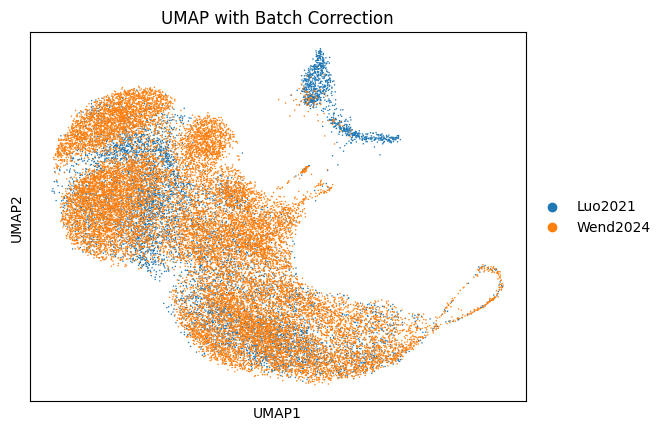

In [9]:

# Paths to datasets
luo_path = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/luo_files/Luo2021nature_new_labels.h5ad'
wend_path = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/wend_files/Wend2024sciadv_two_labels.h5ad'

# Load datasets
adata_luo = sc.read_h5ad(luo_path)
adata_wend = sc.read_h5ad(wend_path)

# Filter cells and genes with relaxed thresholds
sc.pp.filter_cells(adata_luo, min_genes=50)
sc.pp.filter_genes(adata_luo, min_cells=2)
adata_luo.var_names_make_unique()

sc.pp.filter_cells(adata_wend, min_genes=50)
sc.pp.filter_genes(adata_wend, min_cells=2)
adata_wend.var_names_make_unique()

# Normalize, log-transform, and scale each dataset separately
sc.pp.normalize_total(adata_luo, target_sum=1e4)
sc.pp.log1p(adata_luo)
sc.pp.scale(adata_luo)

sc.pp.normalize_total(adata_wend, target_sum=1e4)
sc.pp.log1p(adata_wend)
sc.pp.scale(adata_wend)

# Align genes between datasets
common_genes = list(set(adata_luo.var_names).intersection(set(adata_wend.var_names)))
adata_luo = adata_luo[:, common_genes].copy()
adata_wend = adata_wend[:, common_genes].copy()

# Add batch labels
adata_luo.obs['dataset'] = 'Luo2021'
adata_wend.obs['dataset'] = 'Wend2024'

# Combine datasets
adata_combined = adata_luo.concatenate(adata_wend, batch_key="dataset", batch_categories=["Luo2021", "Wend2024"])

# Perform PCA
sc.tl.pca(adata_combined)

# Option 1: Harmony
sce.pp.harmony_integrate(adata_combined, key="dataset")
sc.pp.neighbors(adata_combined, use_rep="X_pca_harmony")
sc.tl.umap(adata_combined)

# Option 2: BBKNN (Uncomment to try BBKNN)
# bbknn.bbknn(adata_combined, batch_key="dataset")
# sc.tl.umap(adata_combined)

# Visualize UMAP
sc.pl.umap(adata_combined, color=["dataset"], title="UMAP with Batch Correction")


### Now coloring by cell type

/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1832: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/zoezabetian/miniconda3/envs/sims_env_310/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: htt

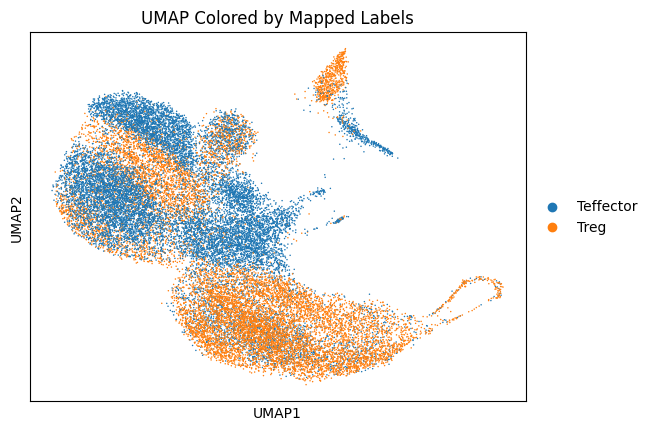

In [12]:
import scanpy as sc
import scanpy.external as sce

# Paths to datasets
luo_path = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/luo_files/Luo2021nature_new_labels.h5ad'
wend_path = '/Users/zoezabetian/Desktop/M-R-lab/leo_project/wend_files/Wend2024sciadv_two_labels.h5ad'

# Load datasets
adata_luo = sc.read_h5ad(luo_path)
adata_wend = sc.read_h5ad(wend_path)

# Filter cells and genes with relaxed thresholds
sc.pp.filter_cells(adata_luo, min_genes=50)
sc.pp.filter_genes(adata_luo, min_cells=2)
adata_luo.var_names_make_unique()

sc.pp.filter_cells(adata_wend, min_genes=50)
sc.pp.filter_genes(adata_wend, min_cells=2)
adata_wend.var_names_make_unique()

# Normalize, log-transform, and scale each dataset separately
sc.pp.normalize_total(adata_luo, target_sum=1e4)
sc.pp.log1p(adata_luo)
sc.pp.scale(adata_luo)

sc.pp.normalize_total(adata_wend, target_sum=1e4)
sc.pp.log1p(adata_wend)
sc.pp.scale(adata_wend)

# Align genes between datasets
common_genes = list(set(adata_luo.var_names).intersection(set(adata_wend.var_names)))
adata_luo = adata_luo[:, common_genes].copy()
adata_wend = adata_wend[:, common_genes].copy()

# Add batch labels
adata_luo.obs['dataset'] = 'Luo2021'
adata_wend.obs['dataset'] = 'Wend2024'

# Map Luo2021 labels to Wend2024 labels
mapping = {'naive': 'Treg', 'effector': 'Teffector'}
adata_luo.obs['mapped_labels'] = adata_luo.obs['treg'].map(mapping)  # Replace 'label_column' with the column name in adata_luo.obs that stores the labels
adata_wend.obs['mapped_labels'] = adata_wend.obs['treg']  # Assume Wend labels are already in the correct format

# Combine datasets
adata_combined = adata_luo.concatenate(
    adata_wend, batch_key="dataset", batch_categories=["Luo2021", "Wend2024"]
)

# Perform PCA
sc.tl.pca(adata_combined)

# Batch correction using Harmony
sce.pp.harmony_integrate(adata_combined, key="dataset")
sc.pp.neighbors(adata_combined, use_rep="X_pca_harmony")
sc.tl.umap(adata_combined)

# Visualize UMAP, coloring by mapped labels
sc.pl.umap(
    adata_combined,
    color=["mapped_labels"],
    title="UMAP Colored by Mapped Labels"
)


In [ ]:
adata_leo